### Import libraries

In [20]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

### Load the saved data

In [21]:
X_train = joblib.load("../../data/processed/X_train_tfidf.pkl")
X_val = joblib.load("../../data/processed/X_val_tfidf.pkl")
X_test = joblib.load("../../data/processed/X_test_tfidf.pkl")

y_train = joblib.load("../../data/processed/y_train.pkl")
y_val = joblib.load("../../data/processed/y_val.pkl")
y_test = joblib.load("../../data/processed/y_test.pkl")

### Train the model


In [22]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Training accuracy

In [23]:
y_train_pred = lr_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.8730


### Evaluate on the validation set

In [24]:
y_val_pred = lr_model.predict(X_val)

print("Validation Accuracy:", val_accuracy := accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8360491071428572
              precision    recall  f1-score   support

    Negative       0.39      0.74      0.51       347
     Neutral       0.19      0.56      0.28       388
    Positive       0.98      0.85      0.91      8225

    accuracy                           0.84      8960
   macro avg       0.52      0.72      0.57      8960
weighted avg       0.92      0.84      0.87      8960



### Final evaluation on the test set

In [25]:
y_test_pred = lr_model.predict(X_test)

print("Test Accuracy:", test_accuracy := accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.8348961821835231
              precision    recall  f1-score   support

    Negative       0.39      0.77      0.51       347
     Neutral       0.20      0.60      0.30       388
    Positive       0.98      0.85      0.91      8223

    accuracy                           0.83      8958
   macro avg       0.52      0.74      0.57      8958
weighted avg       0.93      0.83      0.87      8958



In [26]:
print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy      : {test_accuracy:.4f}")

Training Accuracy   : 0.8730
Validation Accuracy: 0.8360
Test Accuracy      : 0.8349


### Plot the confusion matrix

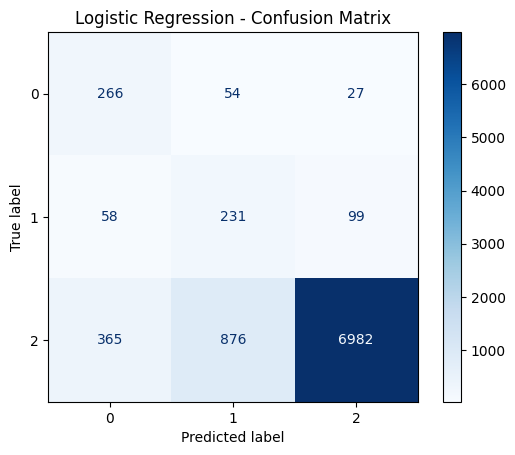

In [27]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Save the trained model

In [28]:
joblib.dump(
    lr_model,
    "../../models/logistic_regression.pkl"
)

['../../models/logistic_regression.pkl']